In [1]:
#Step 1 — Import Libraries
'''
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
'''

'\nimport tensorflow as tf\nimport matplotlib.pyplot as plt\nimport numpy as np\n\nfrom tensorflow.keras.models import Sequential\nfrom tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D\nfrom tensorflow.keras.applications import MobileNetV2\nfrom tensorflow.keras.preprocessing import image\nfrom sklearn.metrics import classification_report, confusion_matrix\nimport seaborn as sns\n'

In [2]:
#Step 1 — Install Required Libraries
!pip install kagglehub

In [3]:
#Step 2 — Import Libraries
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.preprocessing import image

In [4]:
#Step 3 — Download Dataset
import kagglehub

dataset_path = kagglehub.dataset_download(
    "alxmamaev/flowers-recognition"
)

print("Dataset downloaded at:")
print(dataset_path)

100%|██████████| 225M/225M [00:02<00:00, 81.6MB/s]

Extracting files...


Dataset downloaded at:
/root/.cache/kagglehub/datasets/alxmamaev/flowers-recognition/versions/2


In [5]:
print(os.listdir(dataset_path))


['flowers']


In [6]:
#Step 5 — Define Classes
data_dir = os.path.join(
    dataset_path,
    "flowers"
)

print(os.listdir(data_dir))

['dandelion', 'tulip', 'sunflower', 'rose', 'daisy']


In [7]:
#Step 5 — Define Classes
classes = [
    "daisy",
    "dandelion",
    "rose",
    "sunflower",
    "tulip"
]

print(classes)

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


In [8]:
#Step 6 — Collect Image Paths
image_paths = []
labels = []

for label, class_name in enumerate(classes):

    class_folder = os.path.join(
        data_dir,
        class_name
    )

    for file_name in os.listdir(class_folder):

        file_path = os.path.join(
            class_folder,
            file_name
        )

        if file_name.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):

            image_paths.append(file_path)
            labels.append(label)

In [9]:
#Step 7 — Check Total Images
#Check each class:
print("Total Images:", len(image_paths))

Total Images: 4317


In [10]:
#Check each class:
for i, class_name in enumerate(classes):

    count = labels.count(i)

    print(
        class_name,
        ":",
        count
    )

daisy : 764
dandelion : 1052
rose : 784
sunflower : 733
tulip : 984


In [11]:
#Step 8 — Convert to NumPy Arrays
image_paths = np.array(image_paths)
labels = np.array(labels)

print(image_paths.shape)
print(labels.shape)

(4317,)
(4317,)


In [12]:
#Step 9 — Divide Dataset into Training and Temporary Data
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

In [13]:
#Step 10 — Divide Temporary Data into Validation and Testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [14]:
#Step 11 — Check Dataset Sizes
print("Training Images:", len(X_train))
print("Validation Images:", len(X_val))
print("Testing Images:", len(X_test))

Training Images: 3021
Validation Images: 648
Testing Images: 648


In [15]:
print(
    "Total:",
    len(X_train) +
    len(X_val) +
    len(X_test)
)

Total: 4317


In [16]:
#Step 12 — Create Image Loading Function
IMG_SIZE = 224
BATCH_SIZE = 32

In [17]:
#Function:
def load_image(image_path, label):

    image_data = tf.io.read_file(image_path)

    image_data = tf.image.decode_jpeg(
        image_data,
        channels=3
    )

    image_data = tf.image.resize(
        image_data,
        (IMG_SIZE, IMG_SIZE)
    )

    image_data = preprocess_input(
        image_data
    )

    return image_data, label

In [18]:
#Step 13 — Create Training Dataset
train_data = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

train_data = train_data.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_data = train_data.shuffle(
    1000
)

train_data = train_data.batch(
    BATCH_SIZE
)

train_data = train_data.prefetch(
    tf.data.AUTOTUNE
)

In [19]:
#Step 14 — Create Validation Dataset
val_data = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
)

val_data = val_data.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_data = val_data.batch(
    BATCH_SIZE
)

val_data = val_data.prefetch(
    tf.data.AUTOTUNE
)

In [20]:
#Step 15 — Create Testing Dataset
test_data = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)

test_data = test_data.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_data = test_data.batch(
    BATCH_SIZE
)

test_data = test_data.prefetch(
    tf.data.AUTOTUNE
)

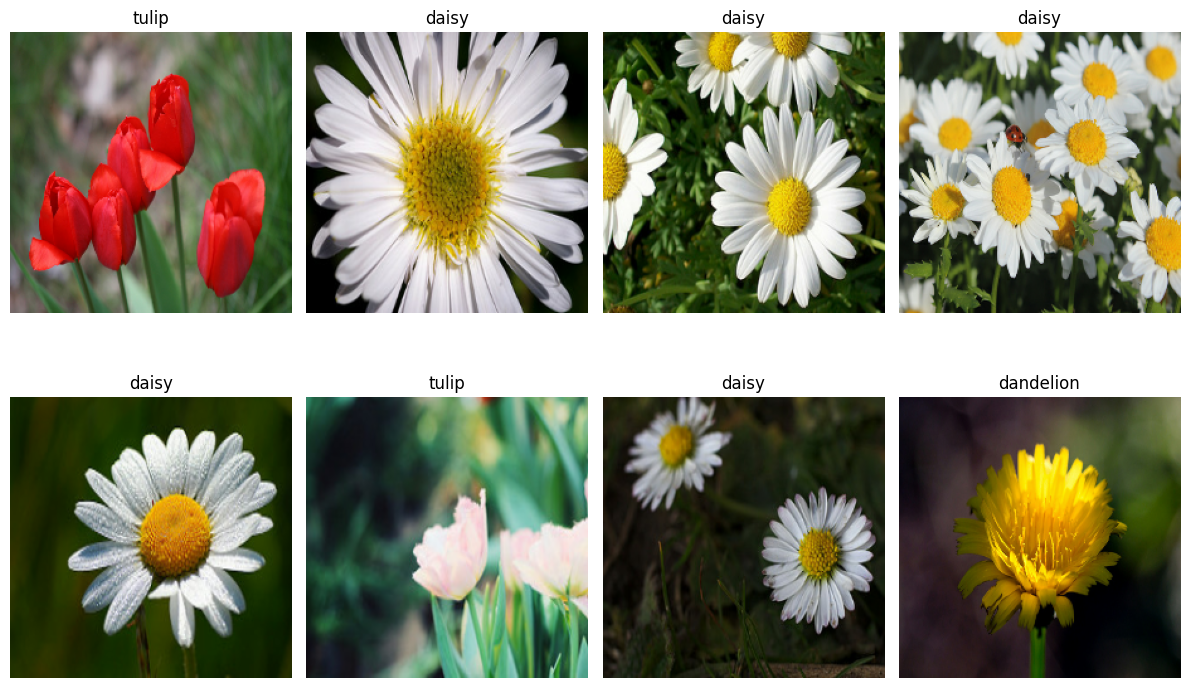

In [21]:
#Step 16 — Display Images
plt.figure(figsize=(12, 8))

for images, labels_batch in train_data.take(1):

    for i in range(8):

        plt.subplot(2, 4, i + 1)

        img = images[i].numpy()

        # Reverse MobileNetV2 preprocessing
        img = (img + 1) / 2

        plt.imshow(img)

        plt.title(
            classes[labels_batch[i].numpy()]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
#Step 17 — Data Augmentation
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    tf.keras.layers.RandomRotation(
        0.1
    ),

    tf.keras.layers.RandomZoom(
        0.1
    )
])

In [23]:
#Step 18 — Load Pretrained MobileNetV2
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [24]:
#Step 19 — Freeze Pretrained Model
base_model.trainable = False

In [25]:
#Step 20 — Build Final Model
model = Sequential([

    data_augmentation,

    base_model,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        5,
        activation="softmax"
    )
])

In [26]:
#Step 21 — Compile Model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [27]:
#Step 22 — Model Summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
#Step 23 — Train the Model
history = model.fit(

    train_data,

    validation_data=val_data,

    epochs=10
)

Epoch 1/10
70/95 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.6011 - loss: 1.0672

In [ ]:
#Step 24 — Test the Model
test_loss, test_accuracy = model.evaluate(
    test_data
)

print(
    "Test Loss:",
    test_loss
)

print(
    "Test Accuracy:",
    test_accuracy
)

In [ ]:
#Step 25 — Accuracy Graph
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Training vs Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [ ]:
#Step 26 — Loss Graph
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Training vs Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [ ]:
#Step 31 — Get Predictions
y_true = []
y_pred = []

In [ ]:
for images, labels_batch in test_data:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        labels_batch.numpy()
    )

    y_pred.extend(
        predicted_classes
    )

In [ ]:
#Step 32 — Classification Report
print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes
    )
)

In [ ]:
#Step 33 — Confusion Matrix
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(
    "Flower Classification Confusion Matrix"
)

plt.show()

In [ ]:
#Step 34 — Save the Model
model.save(
    "flower_mobilenetv2.keras"
)

In [ ]:
#Step 35 — Load Saved Model
model = tf.keras.models.load_model(
    "flower_mobilenetv2.keras"
)

In [ ]:
#Step 36 — Upload a New Flower Image
from google.colab import files

uploaded = files.upload()

In [ ]:
#Step 37 — Load New Image
img = image.load_img(
    img_path,
    target_size=(224, 224)
)

In [ ]:
#Step 38 — Convert Image
img_array = image.img_to_array(
    img
)

img_array = np.expand_dims(
    img_array,
    axis=0
)

img_array = preprocess_input(
    img_array
)

In [ ]:
#Step 39 — Predict Flower
prediction = model.predict(
    img_array
)

predicted_class = np.argmax(
    prediction[0]
)

confidence = (
    np.max(prediction[0]) * 100
)

In [ ]:
#Step 40 — Display Final Prediction
print(
    "Predicted Flower:",
    classes[predicted_class]
)

print(
    "Confidence:",
    round(confidence, 2),
    "%"
)

In [ ]:
#FLOWER DATASET
'''
                      ↓
                Download Dataset
                      ↓
              Select 5 Classes
                      ↓
             Collect Image Paths
                      ↓
          ┌───────────┼───────────┐
          ↓           ↓           ↓
       TRAIN        VALIDATION   TEST
        70%           15%         15%
          ↓           ↓           ↓
          └───────────┼───────────┘
                      ↓
               Image Resize
                 224 × 224
                      ↓
              MobileNetV2
              Pretrained
                      ↓
             Transfer Learning
                      ↓
             New Classifier
                      ↓
                  Training
                      ↓
               model.fit()
                      ↓
               Fine-Tuning
                      ↓
              Final Evaluation
                 /    |    \
                /     |     \
          Accuracy   Loss   Confusion Matrix
                              ↓
                    Classification Report
                              ↓
                     New Flower Image
                              ↓
                         Prediction
                              ↓
             Daisy / Dandelion / Rose /
             Sunflower / Tulip
             '''

plt.figure(figsize=(6, 6))

plt.imshow(img)

plt.title(
    f"Prediction: {classes[predicted_class]}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")

plt.show()

In [ ]:
plt.figure(figsize=(6, 6))

plt.imshow(img)

plt.title(
    f"Prediction: {classes[predicted_class]}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")

plt.show()

In [ ]:
#Final Project Flow

'''

                FLOWER DATASET
                      ↓
                Download Dataset
                      ↓
              Select 5 Classes
                      ↓
             Collect Image Paths
                      ↓
          ┌───────────┼───────────┐
          ↓           ↓           ↓
       TRAIN        VALIDATION   TEST
        70%           15%         15%
          ↓           ↓           ↓
          └───────────┼───────────┘
                      ↓
               Image Resize
                 224 × 224
                      ↓
              MobileNetV2
              Pretrained
                      ↓
             Transfer Learning
                      ↓
             New Classifier
                      ↓
                  Training
                      ↓
               model.fit()
                      ↓
               Fine-Tuning
                      ↓
              Final Evaluation
                 /    |    \
                /     |     \
          Accuracy   Loss   Confusion Matrix
                              ↓
                    Classification Report
                              ↓
                     New Flower Image
                              ↓
                         Prediction
                              ↓
             Daisy / Dandelion / Rose /
             Sunflower / Tulip

             '''